In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Obesity and Lifestyle Data 2.csv')

df.info()

df["Height"] = df['Height'] * 100
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1000 non-null   int64  
 1   Gender                       1000 non-null   object 
 2   Height                       1000 non-null   float64
 3   Weight                       1000 non-null   float64
 4   Family_History_Obesity       1000 non-null   object 
 5   Physical_Activity_Frequency  1000 non-null   float64
 6   Dietary_Habits               1000 non-null   object 
 7   Water_Intake                 1000 non-null   float64
 8   Smoking_Habits               1000 non-null   object 
 9   Alcohol_Consumption          1000 non-null   object 
 10  Obesity_Level                1000 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 86.1+ KB


,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level
0,56,Male,184.0,69.6,Yes,7.4,Balanced,4.4,No,Occasionally,Obese Type I
1,46,Female,172.0,110.1,No,2.8,High-calorie,4.3,Yes,Never,Overweight
2,32,Female,164.0,70.5,Yes,2.8,Low-calorie,1.1,Yes,Never,Normal Weight
3,60,Female,200.0,113.8,No,9.6,Balanced,4.6,No,Frequently,Overweight
4,25,Male,171.0,102.8,Yes,0.1,High-calorie,1.1,No,Never,Normal Weight


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
Family_History_Obesity,0
Physical_Activity_Frequency,0
Dietary_Habits,0
Water_Intake,0
Smoking_Habits,0
Alcohol_Consumption,0


In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1000
Rows after: 1000
Rows removed: 0


In [ ]:
df["Weight"].describe()

,Weight
count,1000.000000
mean,84.831500
std,20.275729
min,50.000000
25%,68.675000
50%,84.750000
75%,102.025000
max,119.800000


In [ ]:
df["Obesity_Level"].value_counts()

,count
Obesity_Level,
Obese Type III,211
Normal Weight,206
Obese Type I,201
Overweight,201
Obese Type II,181


In [ ]:
df.head()
df.tail()

,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level
995,22,Male,156.0,85.2,No,0.7,High-calorie,3.2,Yes,Occasionally,Obese Type II
996,40,Male,171.0,63.6,Yes,6.6,Balanced,3.5,Yes,Frequently,Normal Weight
997,27,Female,152.0,110.1,Yes,6.0,Low-calorie,2.0,Yes,Occasionally,Obese Type II
998,61,Male,187.0,97.4,Yes,4.2,High-calorie,4.2,Yes,Occasionally,Obese Type I
999,19,Male,196.0,108.7,No,4.2,Balanced,3.5,No,Never,Obese Type I


In [ ]:
df.groupby("Obesity_Level")[["Age","Height","Weight","Physical_Activity_Frequency","Water_Intake"]].mean()

,Age,Height,Weight,Physical_Activity_Frequency,Water_Intake
Obesity_Level,,,,,
Normal Weight,40.135922,174.737864,83.248544,4.894175,3.084466
Obese Type I,41.751244,175.925373,83.739801,4.951741,2.891045
Obese Type II,41.519337,174.933702,84.608287,5.108840,2.949724
Obese Type III,40.497630,174.308057,87.101896,4.976303,2.886730
Overweight,41.124378,175.582090,85.363184,4.790050,2.945771


In [ ]:
df["BMI"] = df["Weight"] / (df["Height"] / 100) ** 2

df.head()

,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level,BMI
0,56,Male,184.0,69.6,Yes,7.4,Balanced,4.4,No,Occasionally,Obese Type I,20.557656
1,46,Female,172.0,110.1,No,2.8,High-calorie,4.3,Yes,Never,Overweight,37.216063
2,32,Female,164.0,70.5,Yes,2.8,Low-calorie,1.1,Yes,Never,Normal Weight,26.212076
3,60,Female,200.0,113.8,No,9.6,Balanced,4.6,No,Frequently,Overweight,28.450000
4,25,Male,171.0,102.8,Yes,0.1,High-calorie,1.1,No,Never,Normal Weight,35.156116


In [ ]:
df.drop(["Height", "Weight"], axis=1)

,Age,Gender,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level,BMI
0,56,Male,Yes,7.4,Balanced,4.4,No,Occasionally,Obese Type I,20.557656
1,46,Female,No,2.8,High-calorie,4.3,Yes,Never,Overweight,37.216063
2,32,Female,Yes,2.8,Low-calorie,1.1,Yes,Never,Normal Weight,26.212076
3,60,Female,No,9.6,Balanced,4.6,No,Frequently,Overweight,28.450000
4,25,Male,Yes,0.1,High-calorie,1.1,No,Never,Normal Weight,35.156116
...,...,...,...,...,...,...,...,...,...,...
995,22,Male,No,0.7,High-calorie,3.2,Yes,Occasionally,Obese Type II,35.009862
996,40,Male,Yes,6.6,Balanced,3.5,Yes,Frequently,Normal Weight,21.750282
997,27,Female,Yes,6.0,Low-calorie,2.0,Yes,Occasionally,Obese Type II,47.654086
998,61,Male,Yes,4.2,High-calorie,4.2,Yes,Occasionally,Obese Type I,27.853241


In [ ]:
df.head()

,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level,BMI
0,56,Male,184.0,69.6,Yes,7.4,Balanced,4.4,No,Occasionally,Obese Type I,20.557656
1,46,Female,172.0,110.1,No,2.8,High-calorie,4.3,Yes,Never,Overweight,37.216063
2,32,Female,164.0,70.5,Yes,2.8,Low-calorie,1.1,Yes,Never,Normal Weight,26.212076
3,60,Female,200.0,113.8,No,9.6,Balanced,4.6,No,Frequently,Overweight,28.450000
4,25,Male,171.0,102.8,Yes,0.1,High-calorie,1.1,No,Never,Normal Weight,35.156116


In [ ]:
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

df.head()

Numerical columns:
Index(['Age', 'Height', 'Weight', 'Physical_Activity_Frequency',
       'Water_Intake', 'BMI'],
      dtype='object')

Categorical columns:
Index(['Gender', 'Family_History_Obesity', 'Dietary_Habits', 'Smoking_Habits',
       'Alcohol_Consumption', 'Obesity_Level'],
      dtype='object')


,Age,Gender,Height,Weight,Family_History_Obesity,Physical_Activity_Frequency,Dietary_Habits,Water_Intake,Smoking_Habits,Alcohol_Consumption,Obesity_Level,BMI
0,56,Male,184.0,69.6,Yes,7.4,Balanced,4.4,No,Occasionally,Obese Type I,20.557656
1,46,Female,172.0,110.1,No,2.8,High-calorie,4.3,Yes,Never,Overweight,37.216063
2,32,Female,164.0,70.5,Yes,2.8,Low-calorie,1.1,Yes,Never,Normal Weight,26.212076
3,60,Female,200.0,113.8,No,9.6,Balanced,4.6,No,Frequently,Overweight,28.450000
4,25,Male,171.0,102.8,Yes,0.1,High-calorie,1.1,No,Never,Normal Weight,35.156116


In [ ]:
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

numerical_df = df[numerical_cols]
categorical_df = df[categorical_cols]

print("NUMERICAL DATA")
display(numerical_df.head())

print("CATEGORICAL DATA")
display(categorical_df.head())

NUMERICAL DATA


,Age,Height,Weight,Physical_Activity_Frequency,Water_Intake,BMI
0,56,184.0,69.6,7.4,4.4,20.557656
1,46,172.0,110.1,2.8,4.3,37.216063
2,32,164.0,70.5,2.8,1.1,26.212076
3,60,200.0,113.8,9.6,4.6,28.450000
4,25,171.0,102.8,0.1,1.1,35.156116


CATEGORICAL DATA


,Gender,Family_History_Obesity,Dietary_Habits,Smoking_Habits,Alcohol_Consumption,Obesity_Level
0,Male,Yes,Balanced,No,Occasionally,Obese Type I
1,Female,No,High-calorie,Yes,Never,Overweight
2,Female,Yes,Low-calorie,Yes,Never,Normal Weight
3,Female,No,Balanced,No,Frequently,Overweight
4,Male,Yes,High-calorie,No,Never,Normal Weight


In [ ]:
df = df[["Age", "Height", "Weight", "Physical_Activity_Frequency", "Water_Intake", "BMI", "Gender", "Family_History_Obesity", "Dietary_Habits", "Smoking_Habits", "Alcohol_Consumption", "Obesity_Level"]]
df.head()

,Age,Height,Weight,Physical_Activity_Frequency,Water_Intake,BMI,Gender,Family_History_Obesity,Dietary_Habits,Smoking_Habits,Alcohol_Consumption,Obesity_Level
0,56,184.0,69.6,7.4,4.4,20.557656,Male,Yes,Balanced,No,Occasionally,Obese Type I
1,46,172.0,110.1,2.8,4.3,37.216063,Female,No,High-calorie,Yes,Never,Overweight
2,32,164.0,70.5,2.8,1.1,26.212076,Female,Yes,Low-calorie,Yes,Never,Normal Weight
3,60,200.0,113.8,9.6,4.6,28.450000,Female,No,Balanced,No,Frequently,Overweight
4,25,171.0,102.8,0.1,1.1,35.156116,Male,Yes,High-calorie,No,Never,Normal Weight


In [ ]:
df.groupby("Obesity_Level")[["Age", "BMI", "Weight", "Physical_Activity_Frequency", "Water_Intake"]].mean()

,Age,BMI,Weight,Physical_Activity_Frequency,Water_Intake
Obesity_Level,,,,,
Normal Weight,40.135922,27.851533,83.248544,4.894175,3.084466
Obese Type I,41.751244,27.690626,83.739801,4.951741,2.891045
Obese Type II,41.519337,28.264637,84.608287,5.108840,2.949724
Obese Type III,40.497630,29.143094,87.101896,4.976303,2.886730
Overweight,41.124378,28.257403,85.363184,4.790050,2.945771


In [ ]:
df.groupby("Obesity_Level")[
    ["Gender",
     "Family_History_Obesity",
     "Dietary_Habits",
     "Smoking_Habits",
     "Alcohol_Consumption"]
].value_counts()

Obesity_Level  Gender  Family_History_Obesity  Dietary_Habits  Smoking_Habits  Alcohol_Consumption
Normal Weight  Male    Yes                     Balanced        Yes             Never                  7
               Female  Yes                     High-calorie    No              Never                  6
                                                               Yes             Never                  6
               Male    No                      Low-calorie     No              Occasionally           6
               Female  No                      Balanced        No              Never                  5
                                                                                                     ..
Overweight     Male    No                      Low-calorie     Yes             Frequently             1
                       Yes                     Low-calorie     No              Never                  1
                                                                               Occasionally           1
                                                               Yes             Frequently             1
                                                                               Never                  1
Name: count, Length: 338, dtype: int64

In [ ]:
pd.crosstab(df["Obesity_Level"], df["Family_History_Obesity"])

Family_History_Obesity,No,Yes
Obesity_Level,,
Normal Weight,94,112
Obese Type I,106,95
Obese Type II,88,93
Obese Type III,105,106
Overweight,104,97


In [ ]:
pd.crosstab(df["Obesity_Level"], df["Dietary_Habits"])

Dietary_Habits,Balanced,High-calorie,Low-calorie
Obesity_Level,,,
Normal Weight,73,70,63
Obese Type I,60,80,61
Obese Type II,58,63,60
Obese Type III,81,69,61
Overweight,69,78,54


In [ ]:
pd.crosstab(df["Obesity_Level"], df["Smoking_Habits"])

Smoking_Habits,No,Yes
Obesity_Level,,
Normal Weight,104,102
Obese Type I,105,96
Obese Type II,91,90
Obese Type III,111,100
Overweight,92,109


In [ ]:
pd.crosstab(df["Obesity_Level"], df["Alcohol_Consumption"])

Alcohol_Consumption,Frequently,Never,Occasionally
Obesity_Level,,,
Normal Weight,64,77,65
Obese Type I,62,77,62
Obese Type II,62,62,57
Obese Type III,67,75,69
Overweight,67,66,68


In [ ]:
X = df.drop("Obesity_Level", axis=1)
y = df["Obesity_Level"]

In [ ]:
X.head()

,Age,Height,Weight,Physical_Activity_Frequency,Water_Intake,BMI,Gender,Family_History_Obesity,Dietary_Habits,Smoking_Habits,Alcohol_Consumption
0,56,184.0,69.6,7.4,4.4,20.557656,Male,Yes,Balanced,No,Occasionally
1,46,172.0,110.1,2.8,4.3,37.216063,Female,No,High-calorie,Yes,Never
2,32,164.0,70.5,2.8,1.1,26.212076,Female,Yes,Low-calorie,Yes,Never
3,60,200.0,113.8,9.6,4.6,28.450000,Female,No,Balanced,No,Frequently
4,25,171.0,102.8,0.1,1.1,35.156116,Male,Yes,High-calorie,No,Never


In [ ]:
y.head()

,Obesity_Level
0,Obese Type I
1,Overweight
2,Normal Weight
3,Overweight
4,Normal Weight


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,Age,Height,Weight,Physical_Activity_Frequency,Water_Intake,BMI,Gender_Male,Family_History_Obesity_Yes,Dietary_Habits_High-calorie,Dietary_Habits_Low-calorie,Smoking_Habits_Yes,Alcohol_Consumption_Never,Alcohol_Consumption_Occasionally
0,56,184.0,69.6,7.4,4.4,20.557656,True,True,False,False,False,False,True
1,46,172.0,110.1,2.8,4.3,37.216063,False,False,True,False,True,True,False
2,32,164.0,70.5,2.8,1.1,26.212076,False,True,False,True,True,True,False
3,60,200.0,113.8,9.6,4.6,28.450000,False,False,False,False,False,False,False
4,25,171.0,102.8,0.1,1.1,35.156116,True,True,True,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 13)
(200, 13)
(800,)
(200,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.175


In [ ]:
print(y_pred[:20])

['Normal Weight' 'Obese Type II' 'Normal Weight' 'Normal Weight'
 'Obese Type I' 'Normal Weight' 'Obese Type II' 'Overweight'
 'Normal Weight' 'Overweight' 'Obese Type II' 'Normal Weight'
 'Obese Type III' 'Normal Weight' 'Obese Type III' 'Obese Type III'
 'Overweight' 'Normal Weight' 'Obese Type III' 'Obese Type III']


In [ ]:
print(y_test[:20].values)

['Normal Weight' 'Normal Weight' 'Overweight' 'Obese Type I'
 'Normal Weight' 'Obese Type III' 'Normal Weight' 'Obese Type II'
 'Obese Type I' 'Normal Weight' 'Obese Type I' 'Normal Weight'
 'Overweight' 'Obese Type II' 'Obese Type II' 'Obese Type I'
 'Obese Type III' 'Obese Type II' 'Normal Weight' 'Obese Type III']


In [ ]:
print(y_test.value_counts())

Obesity_Level
Obese Type I      48
Overweight        46
Obese Type II     40
Obese Type III    35
Normal Weight     31
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 7  5  3  9  7]
 [10  8  9 12  9]
 [10  6  3 13  8]
 [ 8  4  3 10 10]
 [10  8  7 14  7]]


In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Weight                              0.139793
BMI                                 0.137413
Physical_Activity_Frequency         0.136952
Age                                 0.131522
Height                              0.129417
Water_Intake                        0.129135
Gender_Male                         0.030144
Smoking_Habits_Yes                  0.030047
Family_History_Obesity_Yes          0.029932
Alcohol_Consumption_Occasionally    0.028100
Alcohol_Consumption_Never           0.027424
Dietary_Habits_Low-calorie          0.025941
Dietary_Habits_High-calorie         0.024179
dtype: float64


In [ ]:
print(df.groupby("Obesity_Level")["BMI"].agg(["min", "max", "mean"]))

                      min        max       mean
Obesity_Level                                  
Normal Weight   13.223657  50.050599  27.851533
Obese Type I    14.156719  51.971405  27.690626
Obese Type II   14.418828  49.809902  28.264637
Obese Type III  13.307035  51.022222  29.143094
Overweight      13.347419  47.060733  28.257403


In [ ]:
df[["BMI", "Weight", "Height", "Obesity_Level"]].head(20)

,BMI,Weight,Height,Obesity_Level
0,20.557656,69.6,184.0,Obese Type I
1,37.216063,110.1,172.0,Overweight
2,26.212076,70.5,164.0,Normal Weight
3,28.450000,113.8,200.0,Overweight
4,35.156116,102.8,171.0,Normal Weight
5,35.517391,106.3,173.0,Obese Type III
6,20.549591,51.3,158.0,Overweight
7,32.520776,117.4,190.0,Obese Type III
8,29.481373,100.9,185.0,Obese Type I
9,27.506655,71.3,161.0,Normal Weight


In [ ]:
model

RandomForestClassifier(random_state=42)

In [ ]:
len(model.estimators_)

100

In [ ]:
model.classes_

array(['Normal Weight', 'Obese Type I', 'Obese Type II', 'Obese Type III',
       'Overweight'], dtype=object)

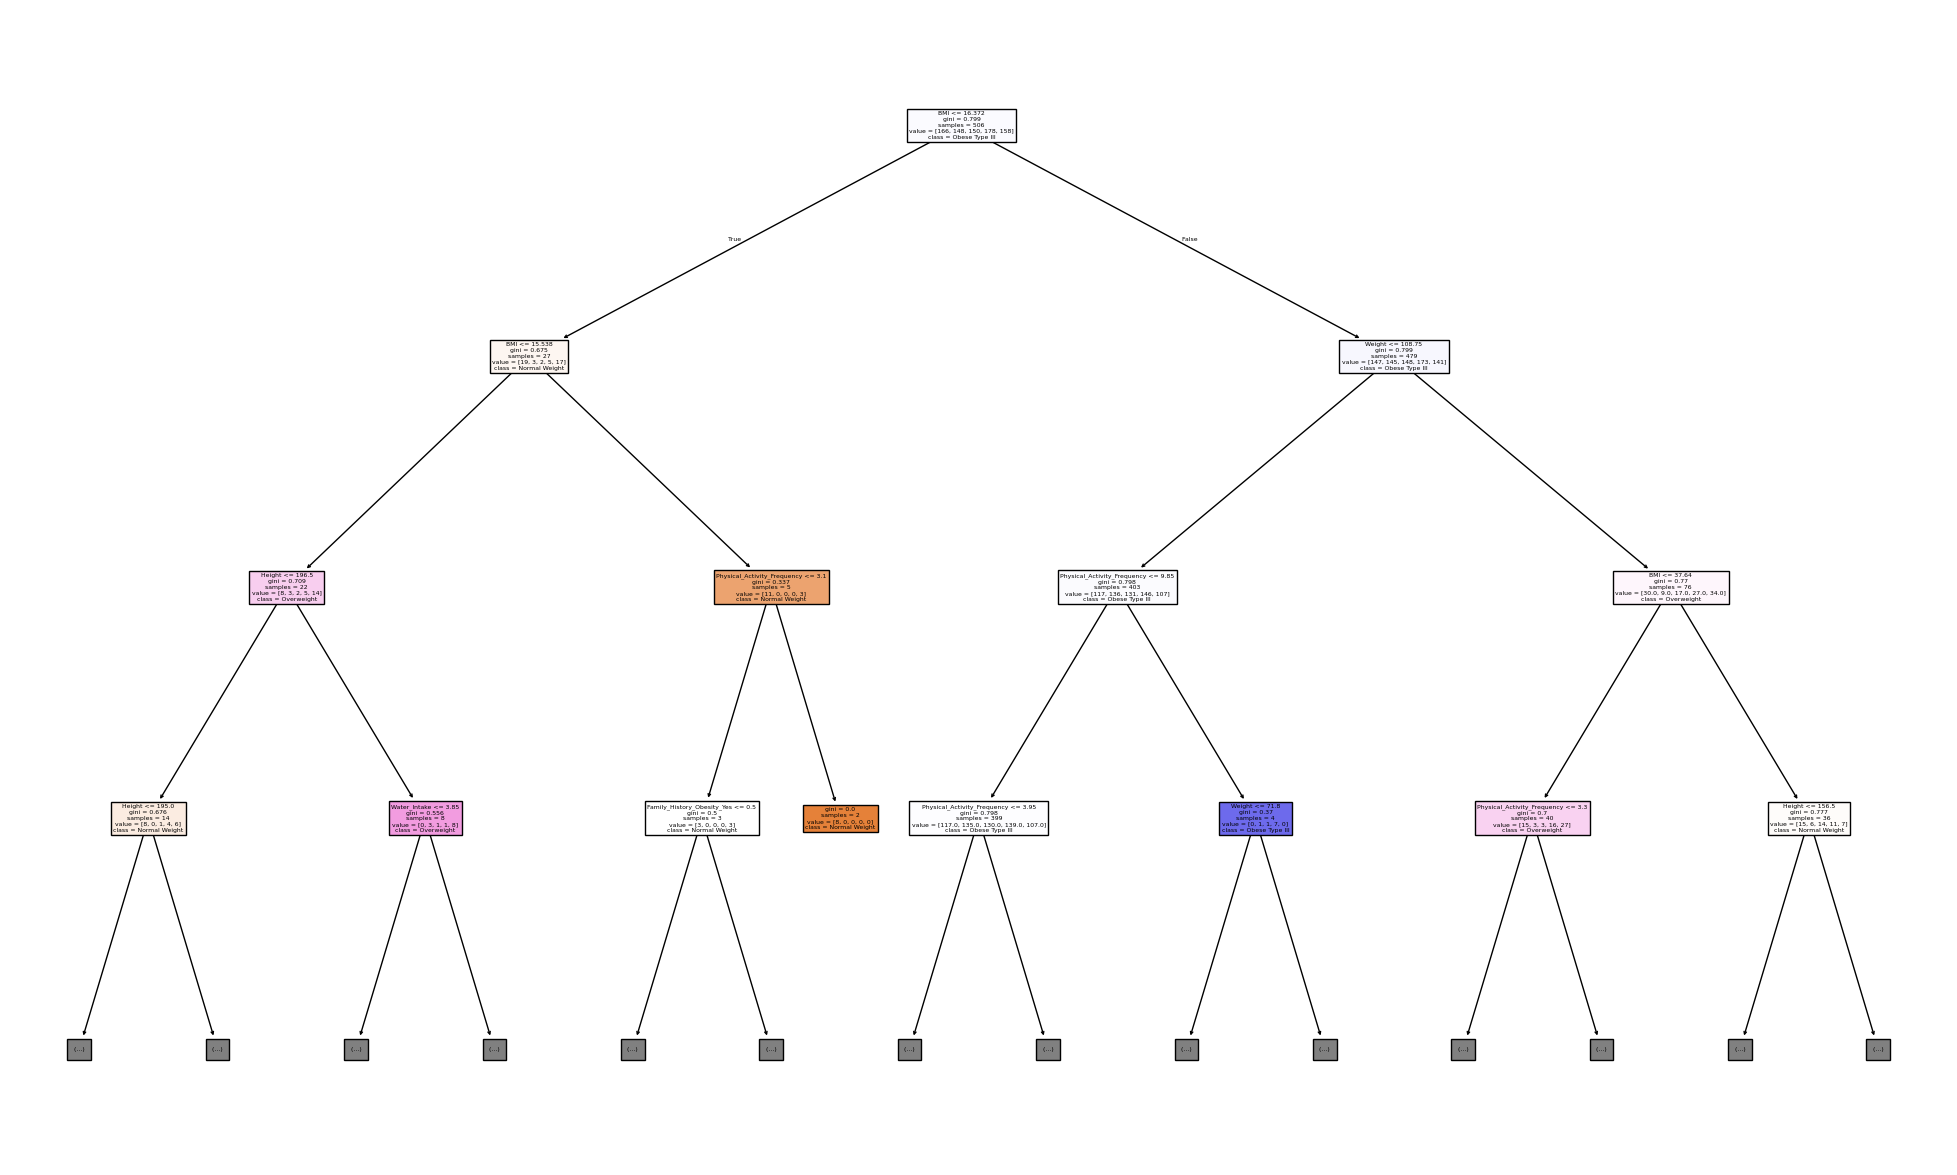

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))

plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    max_depth=3
)

plt.show()